In [177]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [178]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [179]:
""""
X = []
Y = []

for i in classes_in_dir:
    path = '../brain tumor/Brain Tumor Data Set/' + i
    for j in os.listdir(path):
        # Read and resize
        pic = cv2.imread(path + '/' + j, 0)
        pic = cv2.resize(pic, (200, 200))
        
        # Apply augmentation (rotation, zoom, brightness, flip)
        pic = augment_image(pic)
        
        # Add to dataset
        X.append(pic)
        Y.append(classes_in_dir[i])  # label
"""

'"\nX = []\nY = []\n\nfor i in classes_in_dir:\n    path = \'../brain tumor/Brain Tumor Data Set/\' + i\n    for j in os.listdir(path):\n        # Read and resize\n        pic = cv2.imread(path + \'/\' + j, 0)\n        pic = cv2.resize(pic, (200, 200))\n        \n        # Apply augmentation (rotation, zoom, brightness, flip)\n        pic = augment_image(pic)\n        \n        # Add to dataset\n        X.append(pic)\n        Y.append(classes_in_dir[i])  # label\n'

In [180]:
import cv2, numpy as np, random

def safe_augment(img):
    h, w = img.shape[:2]

    # 1️⃣ Small rotation
    angle = random.uniform(-5, 5)
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2️⃣ Slight zoom
    zf = random.uniform(1.0, 1.05)
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]

    # 3️⃣ Brightness adjustment
    beta = random.uniform(-10, 10)
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    #4️⃣ Optional horizontal flip
    if random.random() < 0.5:
         img = cv2.flip(img, 1)

    return img

X, Y = [], []

for i in classes_in_dir:
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, 0)
        pic = cv2.resize(pic, (200, 200))
        pic= safe_augment(pic)

        X.append(pic)
        Y.append(classes_in_dir[i])

       
x = np.array(X, dtype='float32') / 255.0  # normalize
y = np.array(Y)


In [181]:
pd.Series(y).value_counts()

0    2500
1    2500
Name: count, dtype: int64

In [182]:
y.shape

(5000,)

In [183]:
x.shape

(5000, 200, 200)

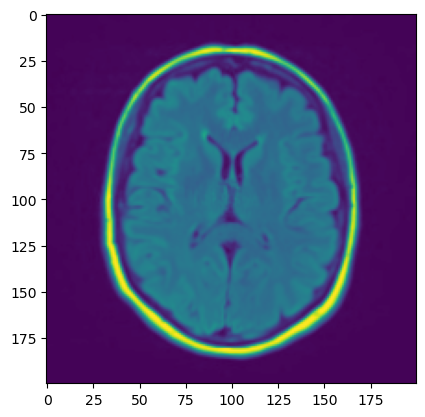

In [184]:
plt.imshow(x[1])


In [185]:
x.shape

(5000, 200, 200)

In [186]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x,y,random_state=42,test_size=0.20)

Text(0.5, 0, '0')

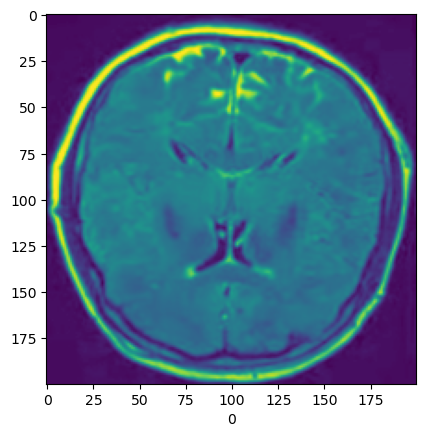

In [187]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


In [188]:
x_train3D.shape

(4000, 200, 200)

#CNN MODEL

In [189]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_10 (Bat  (None, 198, 198, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 99, 99, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_11 (Bat  (None, 97, 97, 64)       256       
 chNormalization)                                                
                                                      

In [190]:
from keras.optimizers import Adam
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [191]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=32)

Epoch 1/3
125/125 [==============================] - 77s 609ms/step - loss: 0.5251 - accuracy: 0.8012 - val_loss: 0.6522 - val_accuracy: 0.5440
Epoch 2/3
125/125 [==============================] - 75s 597ms/step - loss: 0.1804 - accuracy: 0.9268 - val_loss: 0.5471 - val_accuracy: 0.8120
Epoch 3/3
125/125 [==============================] - 74s 592ms/step - loss: 0.0959 - accuracy: 0.9638 - val_loss: 0.3769 - val_accuracy: 0.8860


In [192]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=1)

32/32 [==============================] - 5s 140ms/step - loss: 0.3769 - accuracy: 0.8860


In [193]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

32/32 [==============================] - 5s 139ms/step


In [194]:
print(pred1[0:20])

[0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0]


In [195]:
accuracy_score(y_test3D,pred1)

0.886

In [196]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.87      0.91      0.89       500
           1       0.91      0.86      0.88       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



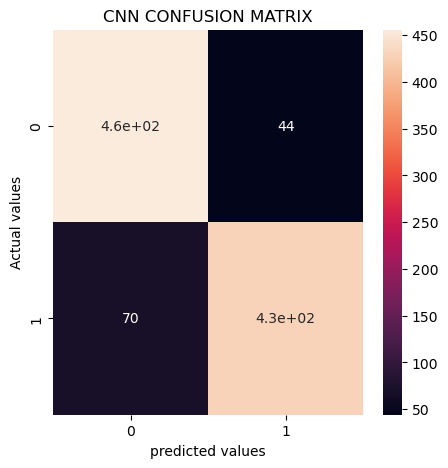

In [197]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [198]:
x_updated=x.reshape(len(x),-1)

In [199]:
x_updated.shape

(5000, 40000)

In [200]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_updated,y,random_state=42,test_size=0.20)

In [201]:
x_train2D.shape

(4000, 40000)

In [202]:
rf=RandomForestClassifier()
rf.fit(x_train2D, y_train2D)

RandomForestClassifier()

In [203]:
pred2=rf.predict(x_test2D)

In [204]:
accuracy_score(y_test2D,pred2)

0.877

In [205]:

conf_mat2=confusion_matrix(y_test2D,pred2)


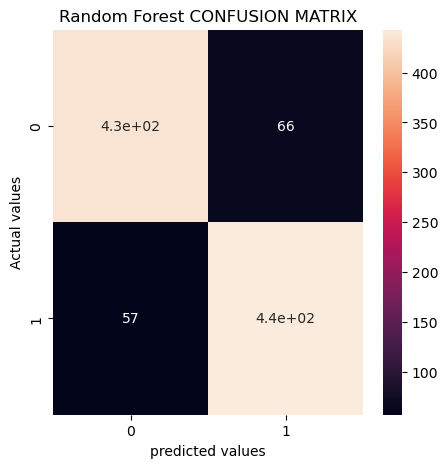

In [206]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [ ]:
# SVM
svm = LinearSVC(max_iter=3000)
svm.fit(x_train2D, y_train2D)

In [208]:
pred3=svm.predict(x_test2D)

In [209]:
accuracy_score(y_test2D,pred3)

0.806

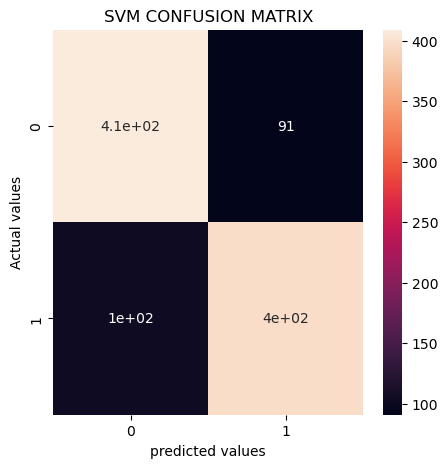

In [210]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [211]:
knn=KNeighborsClassifier(n_neighbors=2, weights='distance')
knn.fit(x_train2D,y_train2D)

KNeighborsClassifier(n_neighbors=2, weights='distance')

In [212]:
pred4=knn.predict(x_test2D)

In [213]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.934

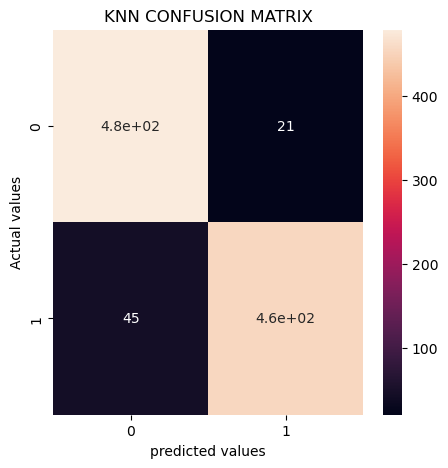

In [214]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [215]:
LR = LogisticRegression(max_iter=10000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=10000)

In [216]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       500
           1       0.82      0.82      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



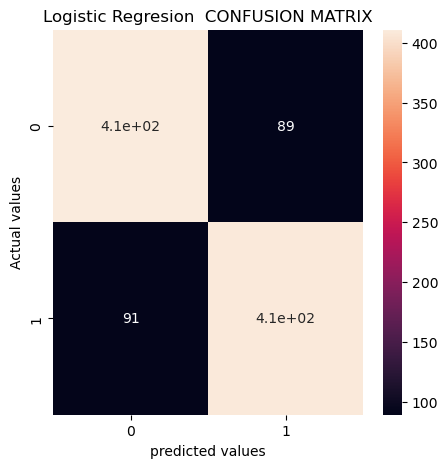

In [217]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

Text(0.5, 0, '1')

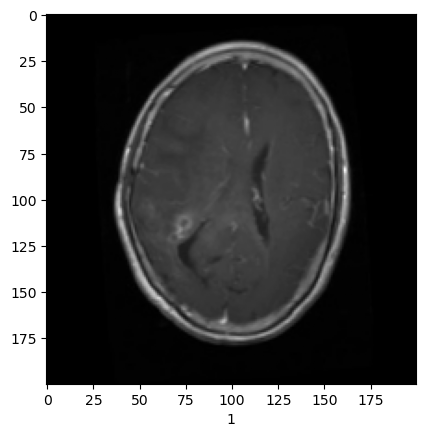

In [218]:
w=plt.imshow(x_test3D[50] ,cmap='gray')
plt.xlabel(y_test3D[50])

In [219]:
f=np.where(y_test3D != pred1)[0]

In [220]:
print(f[0:5])

[ 7 12 14 17 18]


In [221]:
print("Y_test =",y_test2D[103])

Y_test = 1


In [222]:
print("CNN =",pred1[103])

CNN = 1


In [223]:
print("RF =",pred2[103])

RF = 1


In [224]:
print("SVM =",pred3[103])

SVM = 1


In [225]:
print("KNN =",pred4[103])

KNN = 1


In [226]:
print("LR =",pred5[103])

LR = 1


# ALL PREDICTED VALUES

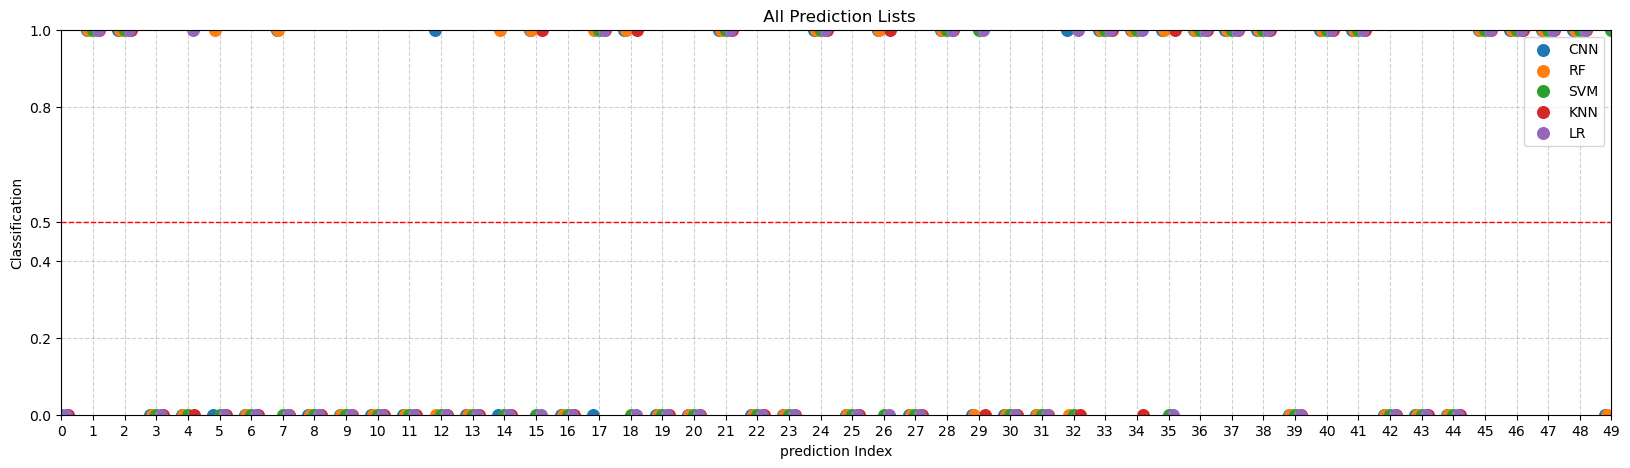

In [227]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [228]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

32/32 [==============================] - 4s 139ms/step


In [229]:
print(pp1[0:2])

[0 1]


In [230]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [231]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[0, 1, 1, 0, 0, 0]


In [232]:
print(y_test3D[0:6])

[0 1 1 0 0 0]


In [ ]:
print(pred1[0:6])

In [234]:
print(pred2[0:6])

[0 1 1 0 0 1]


In [235]:
print(pred3[0:6])

[0 1 1 0 0 0]


In [236]:
print(pred4[0:6])

[0 1 1 0 0 0]


In [237]:
print(pred5[0:6])

[0 1 1 0 1 0]


In [238]:
g=np.where(y_test3D != Ensemble_prediction)[0]
print(g[0:10])

[ 14  18  32  34  49  65  70  78  93 101]


In [239]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.916

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       500
           1       0.92      0.91      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



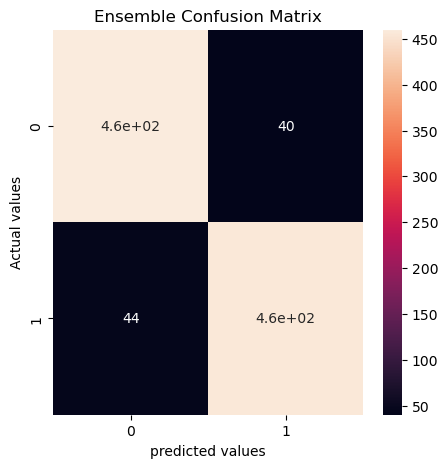

In [240]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

(-0.5, 329.5, 352.5, -0.5)

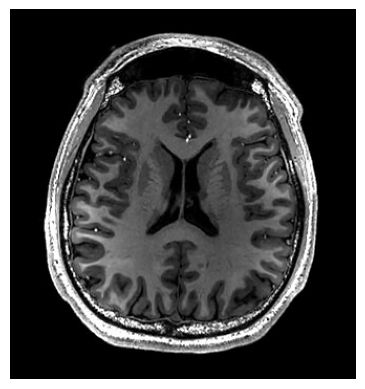

In [241]:
# Path to image
img_path = r"D:\My Final Work\external_pic\12.jpg"  # use raw string to avoid \n errors
# Read image
check_img1 = cv2.imread(img_path,1)
check_img = cv2.imread(img_path,0)
check_img=cv2.resize(check_img,(200,200))
check_img = safe_augment(check_img)
plt.imshow(check_img1)
plt.axis('off')




In [242]:
outside_img =cv2.resize(check_img,(200,200))

In [243]:
outside_img.shape

(200, 200)

In [244]:
cnnpred1=outside_img.reshape(1,200,200)
cnnpred=cnnpred1/255

In [245]:
p1=(cnn.predict(cnnpred)>0.5).astype('int').flatten()

1/1 [==============================] - 0s 49ms/step


In [246]:
print(p1)

[0]


# below is for 2D arrays

In [247]:
p_2D=outside_img.reshape(1, -1)
p_2D.shape

(1, 40000)

In [248]:
p_2D.ndim

2

In [249]:
p_2D=p_2D/255

In [250]:
p2=rf.predict(p_2D)

In [251]:
print(p2)

[0]


In [252]:
p3=svm.predict(p_2D)

In [253]:
print(p3)

[0]


In [254]:
p4=LR.predict(p_2D)

In [255]:
print(p4)

[0]


In [256]:
p5=knn.predict(p_2D)

In [257]:
print(p5)

[1]


In [258]:
if(p1+p2+p3+p4+p5 >= 3):
    print("Tumor")
else:
    print("No Tumor")


No Tumor
